# BERTopic ile hrdergi.com Makalelerinin Konu Modellemesi ve Dinamik Konu Analizi

**Dayanak makale:** Koruyan, K. (2022). *BERTopic Konu Modelleme Tekniği Kullanılarak Müşteri Şikayetlerinin Sınıflandırılması.* İzmir Sosyal Bilimler Dergisi, 4(2), 66-79. DOI: 10.47899/ijss.1167719

Makalenin yöntem hattı, şikâyet metinleri yerine `hrdergi_korpus_final.csv` içindeki **Makale İçeriği** sütununa uygulanır:

| Makaledeki adım | Bu defterdeki karşılığı |
|---|---|
| Ön işleme: noktalama, etkisiz kelime, küçük harf; **kökleme yok** | Bölüm 2 |
| Belge yerleştirme: Sentence-BERT `paraphrase-multilingual-mpnet-base-v2` | Bölüm 3 |
| UMAP ile boyut azaltma + HDBSCAN ile kümeleme | Bölüm 4 |
| c-TF-IDF ile konu temsili, `CountVectorizer` n-gram **(1,2)** | Bölüm 4 |
| `calculate_probabilities=True`, aykırı (-1) belgeler için **olasılık eşiği 0,01** | Bölüm 5 |
| `nr_topics=None` → sonra `"auto"` ile konu azaltma; konu sayısı için **tekrarlı çalıştırma** | Bölüm 4, 6 |
| Tablo 2: konu, kelimeler, frekans, oran, açıklama | Bölüm 7 |
| Şekil 3: c-TF-IDF puanları | Bölüm 7 |
| Tablo 3: konulara ait örnek metinler | Bölüm 8 |
| Dinamik konu modeli (ToT): `global_tuning`, `evolution_tuning`, `nr_bins=12` | Bölüm 9 |
| Şekil 4-5: aylık/dönemsel değişim | Bölüm 9-10 |

**Makaleden farklar (bilinçli uyarlamalar):** makale ~7.700 kısa şikâyet ve **aylık** zaman ekseniyle çalışır. Burada belgeler uzun makaleler olduğu için (i) gömme, başlık + metnin ilk bölümünden üretilir (modelin 128 belirteçlik sınırı nedeniyle), (ii) c-TF-IDF ise tam metin üzerinden hesaplanır, (iii) zaman ekseni **yıldır** (CSV'de ay da var, istenirse `Ay` ile aylık çözünürlük kurulabilir).

> **Gömme modeli notu:** Defter önce makaledeki Sentence-BERT modelini indirmeyi dener (ilk çalıştırmada ~1,1 GB, internet gerekir). Model indirilemezse TF-IDF+SVD gömmesine **otomatik** geçer ve bunu açıkça yazdırır. Yedek yöntemle bulunan konular makaledeki yöntemle birebir karşılaştırılamaz.

## 0. Kurulum ve yollar

In [1]:
# Colab / yerel ortamda bir kez:
# !pip -q install bertopic sentence-transformers umap-learn hdbscan scikit-learn pandas matplotlib openpyxl
import os, re, glob, zipfile, unicodedata, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 100, "display.width", 170)

CSV_ZIP  = "hrdergi_korpus_final.csv.zip"      # veya doğrudan .csv yolu
WORK_DIR = "work_bertopic"
SEED     = 42
os.makedirs(WORK_DIR, exist_ok=True)

# ---- Makaledeki parametreler ----
EMBED_MODEL   = "paraphrase-multilingual-mpnet-base-v2"   # Koruyan (2022)
NGRAM         = (1, 2)
OUTLIER_THR   = 0.01          # olasılık eşiği (makale)
NR_BINS       = 12            # ToT için dilim sayısı (makale)
LEAD_CHARS    = 700           # gömme için metnin ilk bölümü (model 128 belirteç keser)
MIN_CLUSTER   = 15            # HDBSCAN min_cluster_size (BERTopic varsayılanı 10; uzun makalelerde 15)

In [2]:
# CSV'yi bul / aç (macOS zip'lerindeki bozuk dosya adlarına dayanıklı)
def find_csv():
    if CSV_ZIP.lower().endswith(".csv") and os.path.exists(CSV_ZIP):
        return CSV_ZIP
    if os.path.exists(CSV_ZIP):
        with zipfile.ZipFile(CSV_ZIP) as z:
            for zi in z.infolist():
                if zi.filename.lower().endswith(".csv") and "__MACOSX" not in zi.filename:
                    out = os.path.join(WORK_DIR, "korpus.csv")
                    with z.open(zi) as src, open(out, "wb") as dst:
                        dst.write(src.read())
                    return out
    hits = glob.glob("**/*.csv", recursive=True)
    assert hits, "CSV bulunamadı: CSV_ZIP yolunu düzeltin"
    return hits[0]

CSV_PATH = find_csv()
df = pd.read_csv(CSV_PATH)
TEXT, TITLE = "Makale İçeriği", "Makale Başlığı"
df[TEXT] = df[TEXT].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df = df.drop_duplicates(subset=[TITLE, TEXT]).reset_index(drop=True)
df["Yıl"] = pd.to_numeric(df["Yıl"], errors="coerce").astype("Int64")
print(df.shape, "| yıl aralığı:", df["Yıl"].min(), "-", df["Yıl"].max())

(3932, 5) | yıl aralığı: 1997 - 2025


## 2. Ön işleme (makaledeki gibi)

Makale: noktalama temizliği, etkisiz kelime atımı, küçük harf; **kökleme yapılmaz**. İki ayrı metin tutulur:
* `gomme_metni` — Sentence-BERT için doğal metin (başlık + ilk bölüm); dönüştürücüler stopword atılmamış metinle daha iyi çalışır.
* `temiz` — c-TF-IDF için noktalamasız, küçük harfli tam metin (etkisiz kelimeler vektörleyicide atılır).

In [3]:
def tr_lower(s):
    return s.replace("İ", "i").replace("I", "ı").lower()

STOP_TR = sorted(set('''
ve ile ya da de da bir bu şu o için gibi olarak olan daha çok en ise ama fakat ancak veya hem her bazı tüm ki mi mı mu mü
ne nasıl neden kadar sonra önce üzerine üzerinde arasındaki arasında içinde içerisinde ilgili yönelik göre karşı ait
ilk son genel diğer ayrıca sadece bunun bunu bunlar bunların onun onu onlar hatta zaten üzere kendi kendini
olduğu olduğunu olmak olması olabilir olacak oluyor olur olmuştur bulunmaktadır bulunan artık özellikle örneğin
yani çünkü yine hala hâlâ ise hiç hiçbir şey şeyi şeyler kez kere ben sen biz siz onlar bana sana bize size beni seni
bizi sizi onu benim senin bizim sizin diye gibi kadar sanki yalnızca yalnız bile belki ayrı bütün birçok bazen sık
mı mu etmek etmesi etti ediyor edilmesi edilir edilen yapmak yapılan yapılması yapılır yaptı yapıyor yapar
var yok değil değildir vardır gerekir gerekiyor gerekmektedir sayı sayısı dergi hrdergi
'''.split()))

def clean_for_ctfidf(s):
    s = tr_lower(s)
    s = re.sub(r"https?://\S+|www\.\S+", " ", s)
    s = re.sub(r"[^a-zçğıöşüâîû0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

df["temiz"] = df[TEXT].map(clean_for_ctfidf)
df["gomme_metni"] = (df[TITLE].fillna("") + ". " + df[TEXT].str[:LEAD_CHARS]).str.strip()
df["sozcuk"] = df["temiz"].str.split().str.len()
dfa = df[df["sozcuk"] >= 80].reset_index(drop=True)          # çok kısa (ilan/özet) kayıtları dışla
print("Analize giren makale:", len(dfa), "| dışlanan:", len(df) - len(dfa))

Analize giren makale: 3928 | dışlanan: 4


## 3. Belge yerleştirme (embedding)

Makale: Sentence-BERT `paraphrase-multilingual-mpnet-base-v2` (Reimers & Gurevych, 2019). Aşağıda önce bu model denenir; olmazsa TF-IDF+SVD yedeğine düşülür.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

EMBED_BACKEND = None
docs_embed = dfa["gomme_metni"].tolist()
t0 = time.time()
try:
    from sentence_transformers import SentenceTransformer
    st_model = SentenceTransformer(EMBED_MODEL)
    embeddings = st_model.encode(docs_embed, batch_size=32, show_progress_bar=True, normalize_embeddings=True)
    EMBED_BACKEND = f"Sentence-BERT ({EMBED_MODEL})"
except Exception as e:
    print("Sentence-BERT yüklenemedi ->", type(e).__name__, str(e)[:120])
    print("YEDEK: TF-IDF + SVD(100) gömmesi kullanılıyor (makaledeki yöntemle birebir aynı değildir).")
    tf = TfidfVectorizer(max_features=40000, ngram_range=(1, 2), min_df=3, max_df=0.5, sublinear_tf=True,
                         stop_words=STOP_TR, lowercase=False)
    Xtf = tf.fit_transform(dfa["temiz"])
    embeddings = normalize(TruncatedSVD(100, random_state=SEED).fit_transform(Xtf))
    st_model = None
    EMBED_BACKEND = "TF-IDF+SVD(100) [yedek]"
print("Gömme:", EMBED_BACKEND, embeddings.shape, f"({time.time()-t0:.0f} sn)")

Sentence-BERT yüklenemedi -> ProxyError 403 Forbidden
YEDEK: TF-IDF + SVD(100) gömmesi kullanılıyor (makaledeki yöntemle birebir aynı değildir).


Gömme: TF-IDF+SVD(100) [yedek] (3928, 100) (28 sn)


## 4. BERTopic modeli: UMAP → HDBSCAN → c-TF-IDF

`number of topics = None` ile kurulur (makaledeki gibi); konu azaltma ve aykırı değer düzeltmesi sonraki adımlardır. Konu temsili, tam metin üzerinde `CountVectorizer(ngram_range=(1,2))` ile çıkarılır.

In [5]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

def build_model(seed=SEED, min_cluster=MIN_CLUSTER, nr_topics=None):
    umap_m = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=seed)
    hdb_m = HDBSCAN(min_cluster_size=min_cluster, metric="euclidean", cluster_selection_method="eom",
                    prediction_data=True)
    vec_m = CountVectorizer(ngram_range=NGRAM, stop_words=STOP_TR, min_df=3, max_df=0.7)
    m = BERTopic(embedding_model=st_model, umap_model=umap_m, hdbscan_model=hdb_m, vectorizer_model=vec_m,
                 calculate_probabilities=True, nr_topics=nr_topics, top_n_words=10, verbose=False)
    # ÖNEMLİ (Türkçe): BERTopic c-TF-IDF öncesinde metni [^A-Za-z0-9 ] ile temizler; bu ç,ğ,ı,ö,ş,ü harflerini siler
    # ("türkiye" -> "trkiye"). Metni zaten kendimiz temizlediğimiz için bu adımı devre dışı bırakıyoruz.
    m._preprocess_text = lambda documents: documents
    return m

docs = dfa["temiz"].tolist()
topic_model = build_model()
topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)
n_topics0 = len(set(topics)) - (1 if -1 in topics else 0)
print(f"İlk model: {n_topics0} konu | aykırı (-1): {np.mean(np.array(topics) == -1)*100:.1f}%")

İlk model: 48 konu | aykırı (-1): 29.3%


## 5. Aykırı belgelerin azaltılması ve konu sayısının düşürülmesi

Makale: aykırı (-1) belgelere, bir konuya ait olasılığı **0,01** eşiğini aşıyorsa o konu atanır; ardından konu sayısı `auto` ile azaltılır.

In [6]:
new_topics = topic_model.reduce_outliers(docs, topics, probabilities=probs, strategy="probabilities", threshold=OUTLIER_THR)
print(f"Aykırı oranı: {np.mean(np.array(topics) == -1)*100:.1f}% -> {np.mean(np.array(new_topics) == -1)*100:.1f}%")

# Konu temsillerini yeni atamalara göre güncelle (aynı vektörleyiciyle)
# (BERTopic bu adımda "elle atama sonrası konu azaltma" uyarısı verir; makaledeki sıra korunmuştur ve sonuçlar kontrol edilmiştir)
topic_model.update_topics(docs, topics=new_topics,
                          vectorizer_model=CountVectorizer(ngram_range=NGRAM, stop_words=STOP_TR, min_df=3, max_df=0.7))

# nr_topics="auto": benzer konuları birleştir
topic_model.reduce_topics(docs, nr_topics="auto")
final_topics = np.array(topic_model.topics_)
dfa["konu"] = final_topics
n_final = len(set(final_topics)) - (1 if -1 in final_topics else 0)
print(f"Nihai konu sayısı: {n_final} | -1 payı: {np.mean(final_topics == -1)*100:.1f}%")

2026-10-05 08:44:21,550 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Aykırı oranı: 29.3% -> 3.3%


Nihai konu sayısı: 35 | -1 payı: 3.3%


## 6. Konu sayısının kararlılığı (makale: "en uygun konu sayısı bulunana kadar tekrarlandı")

Farklı rastgele tohum ve `min_cluster_size` değerleriyle model yeniden kurulur; bulunan konu sayıları ve aykırı oranları raporlanır. Sonuçlar birbirine yakınsa konu yapısı kararlıdır.

In [7]:
runs = []
for seed in (1, 7, 42):
    for mc in (10, 15, 25):
        m = build_model(seed=seed, min_cluster=mc)
        t, p = m.fit_transform(docs, embeddings=embeddings)
        t2 = m.reduce_outliers(docs, t, probabilities=p, strategy="probabilities", threshold=OUTLIER_THR)
        runs.append(dict(seed=seed, min_cluster=mc,
                         konu_sayisi=len(set(t)) - (1 if -1 in t else 0),
                         aykiri_ilk_pct=round(np.mean(np.array(t) == -1) * 100, 1),
                         aykiri_son_pct=round(np.mean(np.array(t2) == -1) * 100, 1)))
stab = pd.DataFrame(runs)
display(stab)
print("Konu sayısı: ortalama %.1f, aralık %d-%d" % (stab.konu_sayisi.mean(), stab.konu_sayisi.min(), stab.konu_sayisi.max()))

,seed,min_cluster,konu_sayisi,aykiri_ilk_pct,aykiri_son_pct
0,1,10,78,26.5,5.8
1,1,15,44,29.4,8.4
2,1,25,31,34.5,7.1
3,7,10,71,22.3,7.5
4,7,15,46,27.2,6.4
5,7,25,29,32.2,8.5
6,42,10,86,23.6,6.3
7,42,15,48,29.3,3.3
8,42,25,30,33.7,4.4


Konu sayısı: ortalama 51.4, aralık 29-86


## 7. Sonuçlar — Tablo 2 benzeri konu tablosu ve c-TF-IDF grafiği (Şekil 3)

`Açıklama` sütunu makaledeki gibi **araştırmacı tarafından** verilir; aşağıda ilk taslak otomatik önerilir (en belirgin 3 sözcük), kendi yorumunuzla değiştirin.

In [8]:
info = topic_model.get_topic_info()
info = info.rename(columns={"Topic": "ID", "Count": "Frekans"})
info["Oran_%"] = (info["Frekans"] / info["Frekans"].sum() * 100).round(2)
info["Kelimeler"] = [", ".join(w for w, _ in topic_model.get_topic(t)[:5]) if t != -1 else "aykırı belgeler" for t in info["ID"]]
info["Açıklama (taslak)"] = [" / ".join(w for w, _ in topic_model.get_topic(t)[:3]) if t != -1 else "Aykırı" for t in info["ID"]]
topic_table = info[["ID", "Kelimeler", "Frekans", "Oran_%", "Açıklama (taslak)"]].sort_values("Frekans", ascending=False)
display(topic_table.head(25))
print("Toplam:", topic_table["Frekans"].sum())

,ID,Kelimeler,Frekans,Oran_%,Açıklama (taslak)
1,0,"çalışanlarımızın, çalışanlarımız, türk, sene, türkiye nin",1149,29.25,çalışanlarımızın / çalışanlarımız / türk
2,1,"ilişkisel, yedekleme, michael, etik, başkan",326,8.30,ilişkisel / yedekleme / michael
3,2,"yapay, zekâ, yapay zekâ, dijital, pozitif",261,6.64,yapay / zekâ / yapay zekâ
4,3,"başlıklı, zirvede, belirtti, belirten, paylaştı",195,4.96,başlıklı / zirvede / belirtti
5,4,"uzaktan, hibrit, kuşağı, sanal, ofise",185,4.71,uzaktan / hibrit / kuşağı
6,5,"istanbul, fotoğraf, müzik, kendimi, türk",152,3.87,istanbul / fotoğraf / müzik
0,-1,aykırı belgeler,131,3.34,Aykırı
7,6,"anket, getirisi, yatırım getirisi, outplacement, eğitimin",102,2.60,anket / getirisi / yatırım getirisi
8,7,"kurumlar, sessiz, kurumların, görünmeyen, görünür",99,2.52,kurumlar / sessiz / kurumların
9,8,"istanbul, toplum, vakfı, sanat, sivil",91,2.32,istanbul / toplum / vakfı


Toplam: 3928


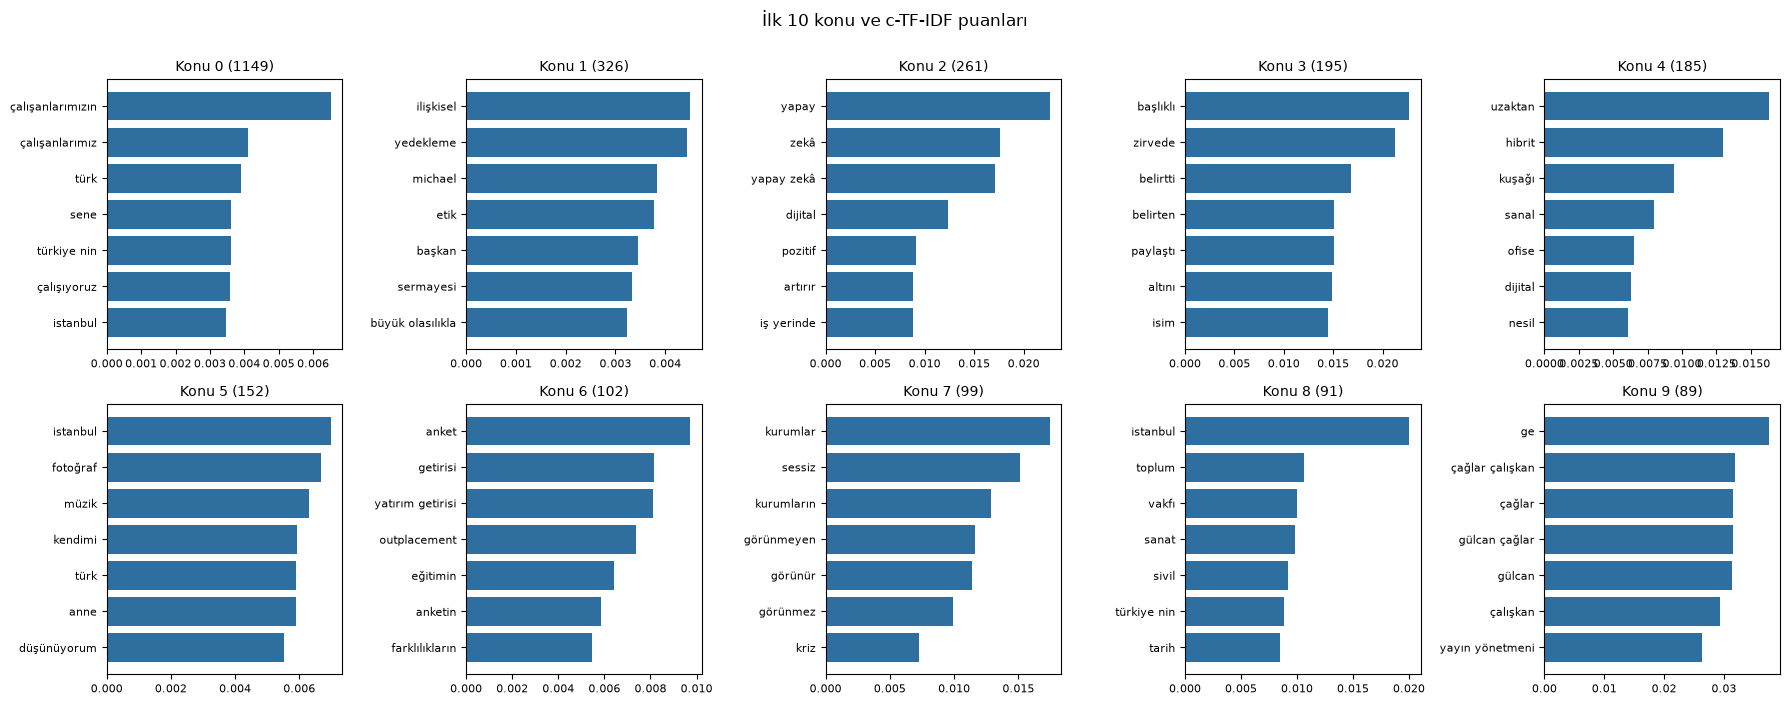

In [9]:
# Şekil 3: ilk N konu ve c-TF-IDF puanları
top_ids = [t for t in topic_table["ID"] if t != -1][:10]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, t in zip(axes.ravel(), top_ids):
    words = topic_model.get_topic(t)[:7][::-1]
    ax.barh([w for w, _ in words], [s for _, s in words], color="#2f6f9f")
    ax.set_title(f"Konu {t} ({int(info.loc[info.ID == t, 'Frekans'].iloc[0])})", fontsize=10)
    ax.tick_params(labelsize=8)
fig.suptitle("İlk 10 konu ve c-TF-IDF puanları", y=1.0)
plt.tight_layout(); plt.savefig(f"{WORK_DIR}/ctfidf_ilk10.png", dpi=150); plt.show()

## 8. Tablo 3 benzeri: konulara ait örnek makaleler

In [10]:
# Her konunun, konuya ait olasılığı en yüksek makaleleri (temsili belgeler)
probs_final = np.asarray(probs)
rows = []
for t in top_ids[:10]:
    idx = np.where(final_topics == t)[0]
    # olasılık matrisi ilk modelin konu dizilimine göre; azaltma sonrası kayabilir -> başlık uzunluğu yerine merkeze yakınlık kullan
    cen = embeddings[idx].mean(axis=0)
    best = idx[np.argsort(-(embeddings[idx] @ cen))[:2]]
    for b in best:
        rows.append((t, int(dfa.loc[b, "Yıl"]), dfa.loc[b, TITLE][:110], dfa.loc[b, TEXT][:250] + "…", dfa.loc[b, "URL"]))
examples = pd.DataFrame(rows, columns=["Konu", "Yıl", "Başlık", "Metin (ilk 250 kr.)", "URL"])
display(examples)

,Konu,Yıl,Başlık,Metin (ilk 250 kr.),URL
0,0,2010,Türkiye İş Bankası İnsan Kaynakları: “İK’yı bankanın stratejik bir ortağı haline getirmek ve str...,Ocak 2010 Sayısı Türkiye İş Bankası İnsan Kaynakları: “İK’yı bankanın stratejik bir ortağı halin...,https://hrdergi.com/turkiye-is-bankasi-insan-kaynaklari-ik-yi-bankanin-stratejik-bir-ortagi-hali...
1,0,2007,"TAV Havalimanları Holding İnsan Kaynakları Direktörü Özlem Tekay: “Alman yöneticisi, Japon mühen...",İK süreçleriniz hakkında konuşmaya başlamadan önce biraz TAV organizasyon yapısı hakkında bilgi ...,https://hrdergi.com/tav-havalimanlari-holding-insan-kaynaklari-direktoru-ozlem-tekay-alman-yonet...
2,1,2005,"“Hedefiniz sadece ayakta kalmak değil ilerlemek ve zenginleşmekse, yalın bir öğrenen organizasyo...",HR Dergi: Toyota ilk olarak 1980’lerde dünyanın dikkatini çekti. Ama sizin kitabınız bugün bile ...,https://hrdergi.com/hedefiniz-sadece-ayakta-kalmak-degil-ilerlemek-ve-zenginlesmekse-yalin-bir-o...
3,1,2005,“İK’cılar ‘Kral Çıplak’ diyebilmeli”,HR Dergi: Okurlarınızdan biri kitabınızla ilgili şu yorumu yapıyor: “Kitap sıra dışı çünkü kişin...,https://hrdergi.com/ik-cilar-kral-ciplak-diyebilmeli
4,2,2025,Yetenek Yönetimi Trendleri: 2025 İnsan Potansiyelinin Dijital Çağda Yeniden Keşfi,"Yetenek yönetimi, modern iş dünyasında yalnızca bir strateji değil, aynı zamanda rekabet avantaj...",https://hrdergi.com/yetenek-yonetimi-trendleri-2025
5,2,2024,Geleceğin İK’sını tehdit eden korku ve zorluklar!,"Günümüzde, iş dünyası sürekli değişen bir paradigma içerisinde evrim geçiriyor ve bu değişimleri...",https://hrdergi.com/gelecegin-iksini-tehdit-eden-korku-ve-zorluklar
6,3,2014,Stratejik İK Yönetimi’ne ilişkin her şey…,HRdergi olarak 4 Mart tarihinde Assessment Systems ve Masters Training International’ın Resmi Sp...,https://hrdergi.com/stratejik-ik-yonetimi-ne-iliskin-her-sey
7,3,2012,Performansı zirveye taşıdık!,"Bütçelemenin ötesinde… 13. Performans Yönetimi Zirvesi’nin bu yılki ana konuşmacısı, Statoil Per...",https://hrdergi.com/performansi-zirveye-tasidik
8,4,2022,2023 için 11 İK Trendi: 2023 İK’nın fırsat yılı olacak!,"2023, değişen bir çalışma dünyasını getiriyor. Pandemi, dijital dönüşümü dört yıl ileriye taşıdı...",https://hrdergi.com/2023-icin-11-ik-trendi-2023-iknin-firsat-yili-olacak
9,4,2022,Büyük İstifa’yı Büyük Yenilenme’ye dönüştürün! Her şey dönüşürken Yetenek Savaşları dönüşmedi mi?,"2020'de pandeminin başlangıcında, pek çok İK departmanı, şüphesiz işten çıkarmalar, izinler ve g...",https://hrdergi.com/buyuk-istifayi-buyuk-yenilenme’ye-donusturun-her-sey-donusurken-yetenek-sava...


## 9. Dinamik konu modeli (ToT) — Şekil 4 benzeri

Makaledeki ayarlar: `global_tuning=True`, `evolution_tuning=True`, `nr_bins=12`. Makalede zaman damgası şikâyet tarihidir (aylık); burada makale **yılı** kullanılır.

(334, 4)


,Topic,Words,Frequency,Timestamp
0,0,"işletme, türk, toplam kalite, eleman, örgütsel",162,1996.972
1,1,"mizah, eğlence, eğlenceli, değişimle başa, çirkin",1,1996.972
2,2,"yokluğu, problemler, riskler, gösterilen, destekleyici",1,1996.972
3,3,"belirtti, dr, vurguladı, konusuyla, ticaret",3,1996.972
4,5,"mehmet, selin, yemek, balık, eryılmaz",25,1996.972


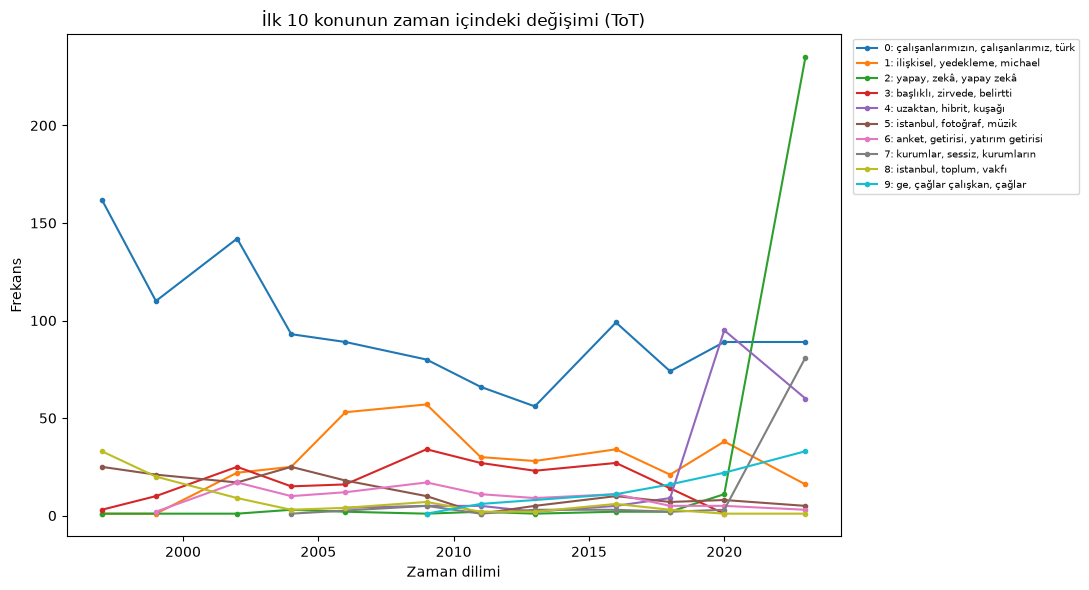

In [11]:
timestamps = dfa["Yıl"].astype(int).tolist()
tot = topic_model.topics_over_time(docs, timestamps, global_tuning=True, evolution_tuning=True, nr_bins=NR_BINS)
print(tot.shape); display(tot.head())
tot["Timestamp"] = tot["Timestamp"].astype(float).round(0).astype(int)      # dilim ortası -> yıl

fig, ax = plt.subplots(figsize=(11, 6))
for t in top_ids[:10]:
    s = tot[tot.Topic == t].sort_values("Timestamp")
    label = f"{t}: " + ", ".join(w for w, _ in topic_model.get_topic(t)[:3])
    ax.plot(s["Timestamp"], s["Frequency"], marker="o", ms=3, label=label)
ax.set_xlabel("Zaman dilimi"); ax.set_ylabel("Frekans"); ax.set_title("İlk 10 konunun zaman içindeki değişimi (ToT)")
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.savefig(f"{WORK_DIR}/tot_ilk10.png", dpi=150); plt.show()

## 10. Şekil 5 benzeri: dönemlere göre en belirgin konular ve kelimeleri

In [12]:
dfa["donem"] = pd.cut(dfa["Yıl"].astype(float), bins=[1995, 2004, 2009, 2014, 2019, 2022, 2030],
                      labels=["≤2004", "2005-09", "2010-14", "2015-19", "2020-22", "2023+"])
share = (pd.crosstab(dfa["donem"], dfa["konu"], normalize="index") * 100).round(1)
share = share.drop(columns=[-1], errors="ignore")
lines = []
for d in share.index:
    top5 = share.loc[d].sort_values(ascending=False).head(5)
    for t, v in top5.items():
        lines.append((d, t, v, ", ".join(w for w, _ in topic_model.get_topic(t)[:4])))
period_top = pd.DataFrame(lines, columns=["Dönem", "Konu", "Pay_%", "Kelimeler"])
display(period_top)

# Yükselen / düşen konular (ilk ve son dönem payı farkı)
delta = (share.iloc[-1] - share.iloc[0]).sort_values()
fmt = lambda s: pd.DataFrame({"Konu": s.index, "Δ_puan": s.values.round(1),
                              "Kelimeler": [", ".join(w for w, _ in topic_model.get_topic(t)[:4]) for t in s.index]})
print("En çok gerileyen:"); display(fmt(delta.head(8)))
print("En çok yükselen:"); display(fmt(delta.tail(8).iloc[::-1]))

,Dönem,Konu,Pay_%,Kelimeler
0,≤2004,0,51.9,"çalışanlarımızın, çalışanlarımız, türk, sene"
1,≤2004,5,7.9,"istanbul, fotoğraf, müzik, kendimi"
2,≤2004,8,7.8,"istanbul, toplum, vakfı, sanat"
3,≤2004,3,4.8,"başlıklı, zirvede, belirtti, belirten"
4,≤2004,13,4.8,"işveren, işverenin, işçinin, kanunu"
5,2005-09,0,32.4,"çalışanlarımızın, çalışanlarımız, türk, sene"
6,2005-09,1,16.8,"ilişkisel, yedekleme, michael, etik"
7,2005-09,5,7.0,"istanbul, fotoğraf, müzik, kendimi"
8,2005-09,3,5.8,"başlıklı, zirvede, belirtti, belirten"
9,2005-09,6,5.5,"anket, getirisi, yatırım getirisi, outplacement"


En çok gerileyen:


,Konu,Δ_puan,Kelimeler
0,0,-37.9,"çalışanlarımızın, çalışanlarımız, türk, sene"
1,8,-7.6,"istanbul, toplum, vakfı, sanat"
2,5,-7.1,"istanbul, fotoğraf, müzik, kendimi"
3,3,-4.8,"başlıklı, zirvede, belirtti, belirten"
4,13,-4.8,"işveren, işverenin, işçinin, kanunu"
5,16,-4.4,"emeklilik, esop, milyar, bireysel emeklilik"
6,22,-3.1,"mülakat, adayın, aday, görüşme"
7,6,-1.9,"anket, getirisi, yatırım getirisi, outplacement"


En çok yükselen:


,Konu,Δ_puan,Kelimeler
0,2,36.7,"yapay, zekâ, yapay zekâ, dijital"
1,7,12.8,"kurumlar, sessiz, kurumların, görünmeyen"
2,4,9.4,"uzaktan, hibrit, kuşağı, sanal"
3,11,5.2,"dr, prof dr, prof, uzmanı"
4,9,5.2,"ge, çağlar çalışkan, çağlar, gülcan çağlar"
5,15,4.6,"şehir, şehrin, ziyaret, muhteşem"
6,29,0.5,"derecelendirme, performans yönetim, çapraz, karma"
7,12,0.5,"okr, emin olun, kullanın, olursunuz"


## 11. Dışa aktarım ve yöntem notları

In [13]:
out = f"{WORK_DIR}/hrdergi_bertopic_sonuclar.xlsx"
with pd.ExcelWriter(out) as xw:
    topic_table.to_excel(xw, sheet_name="konu_tablosu", index=False)
    stab.to_excel(xw, sheet_name="kararlilik", index=False)
    examples.to_excel(xw, sheet_name="ornek_makaleler", index=False)
    tot.to_excel(xw, sheet_name="topics_over_time", index=False)
    period_top.to_excel(xw, sheet_name="donem_konu", index=False)
    dfa[[ "Yıl", "Ay", TITLE, "konu", "URL"]].to_excel(xw, sheet_name="makale_konu", index=False)
print("Yazıldı:", out)
print("Gömme yöntemi:", EMBED_BACKEND)
# topic_model.save(f"{WORK_DIR}/bertopic_model", serialization="safetensors")   # isteğe bağlı

Yazıldı: work_bertopic/hrdergi_bertopic_sonuclar.xlsx
Gömme yöntemi: TF-IDF+SVD(100) [yedek]


## Yorum ve sınırlılıklar
* **Gömme yöntemi:** Raporlarken hangi gömmenin kullanıldığını belirtin (`EMBED_BACKEND`). Makaledeki sonuçlara benzer bir hat için Sentence-BERT ile çalıştırın.
* **Belge birimi:** Gömme yalnızca başlık + ilk ~700 karakterden üretilir; uzun makalelerin sonraki bölümleri gömmeye girmez (c-TF-IDF ise tam metindedir). Paragraf düzeyinde modelleme için makaleleri parçalayıp aynı hattı çalıştırabilirsiniz.
* **Rastgelelik:** UMAP/HDBSCAN rastgele tohuma duyarlıdır; Bölüm 6 bu duyarlılığı gösterir. Makale de modeli birden çok kez çalıştırdığını belirtir.
* **Etiketleme:** `Açıklama` sütunu otomatik taslaktır; makaledeki gibi konu etiketlerini araştırmacı vermelidir. Birkaç konuda 20-30 makale okuyarak doğrulayın.
* **Aykırılar:** `-1` payı bölüm 5'te eşikle azaltıldı; kalan aykırılar "ortak/karışık" içerik olarak yorumlanabilir.